# Проект: Исследование стартапов

## Введение

### Описание проекта 
Финансовая компания, которая предоставляет льготные займы стартапам, хочет войти на инвестиционный рынок с прицелом на покупку, развитие и последующую перепродажу перспективных стартапов. Для разработки модели бизнеса нужна информация. Чтобы выработать общее понимание, какие данные могут быть полезны, проводится исследование на исторических данных.

### Цель проекта 
Подготовить датасет и проверить, что данные в нём соответствуют здравому смыслу, а также ответить на вопросы заказчика как о предобработке, так и о значении данных для бизнеса. 

В процессе работы необходимо принять решения:
- по каким столбцам можно объединять данные из разных таблиц;
- можно ли доверять данным о сотрудниках стартапов и их образовании;
- что означают покупки за 0 или за 1 доллар;
- какая цена в зависимости от категории стартапов и количества раундов финансирования перед его покупкой;
- как рассчитать и отобразить численные показатели и динамику.
Хорошо, если в процессе работы получится выявить показатели и признаки, которые указывают на повышенную вероятность успешной сделки по покупке компании. 

### Описание данных 

#### Таблица acquisition
Содержит информацию о покупках одними компаниями других компаний:
- id — идентификатор покупки.
- acquiring_company_id — идентификатор покупающей компании.
- acquired_company_id — идентификатор покупаемой компании.
- term_code — варианты расчёта.
- price_amount — сумма сделки.
- acquired_at — дата сделки.

#### Таблица company_and_rounds
Содержит информацию о компаниях и раундах финансирования:
- company ID — идентификатор компании.
- name — название компании.
- category code — категория области деятельности компании.
- status — статус компании.
- founded at — дата инвестирования.
- closed at — дата закрытия компании.
- domain — официальный сайт компании.
- network username — ник компании в сети.
- country code — код страны компании.
- investment rounds — число инвестиционных раундов.
- funding rounds — число раундов финансирования.
- funding total — сумма финансирования.
- milestones — вехи финансирования.
- funding round id — идентификатор этапа финансирования.
- company id — идентификатор компании.
- funded at — дата финансирования.
- funding round type — тип финансирования.
- raised amount — сумма финансирования.
- pre money valuation — предварительная денежная оценка.
- participants — число участников.
- is first round — является ли раунд первым.
- is last round — является раунд последним.

#### Таблица education
Содержит информацию об образовании сотрудника:
- id — идентификатор записи об образовании.
- person_id — идентификатор работника.
- instituition — название учебного заведения.
- graduated_at — дата получения образования. 

#### Таблица people
Содержит информацию о сотрудниках:
- id — идентификатор сотрудника.
- first_name — имя сотрудника.
- last_name — фамилия сотрудника.
- company_id — идентификатор компании.
- network_username — ник в социальных сетях.

#### Таблица degrees
Содержит информацию о типе образования сотрудника:
- id — идентификатор записи.
- object_id — идентификатор сотрудника.
- degree_type — тип образования.
- subject — специальность.

#### Дополнительные датасеты
##### Таблица fund
Содержит информацию о фондах:
- id — идентификатор фонда.
- name — название фонда.
- category_code — категория области деятельности компании.
- founded_at — дата создания фонда.
- domain — сайт фонда.
- network_username — ник фонда в сети.
- country_code — код страны фонда.
- investment_rounds — число инвестиционных раундов.
- invested_companies — число профинансированных компаний.
- milestones — вехи финансирования.

##### Таблица investment
Содержит информацию о раундах инвестирования:
- id — идентификатор этапа инвестирования.
- funding_round_id — идентификатор раунда инвестирования.
- company_id — индентификатор компании.
- funding_round_type — тип финансирования.
- fund_id — идентификатор фонда.



## Шаг 1. Знакомство с данными: загрузка и первичная предобработка

Названия файлов:
* acquisition.csv
* company_and_rounds.csv
* people.csv
* education.csv
* degrees.csv

Опциональные датасеты:
* fund.csv
* investment.csv

### 1.1. Вывод общей информации, исправление названия столбцов

- Загрузить все данные по проекту.
- Проверить названия столбцов.
- Вывести информацию, которая необходима для принятия решений о предобработке, для каждого из датасетов.

In [1]:
# загружаем библиотеку для форматирования кода
!pip install jupyter_black -q

In [2]:
import jupyter_black

jupyter_black.load()

In [3]:
# импортируем библиотеки для работы
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# импортируем датасеты

df_acq = pd.read_csv("https://code.s3.yandex.net/datasets/acquisition.csv")
df_cr = pd.read_csv("https://code.s3.yandex.net/datasets/company_and_rounds.csv")
df_people = pd.read_csv("https://code.s3.yandex.net/datasets/people.csv")
df_ed = pd.read_csv("https://code.s3.yandex.net/datasets/education.csv")
df_degrees = pd.read_csv("https://code.s3.yandex.net/datasets/degrees.csv")
df_fund = pd.read_csv("https://code.s3.yandex.net/datasets/fund.csv")
df_invest = pd.read_csv("https://code.s3.yandex.net/datasets/investment.csv")

In [7]:
def basic_info(df):
    """
    Функция принимает датафрейм, выводит основную информацию о датафрейме.
    Параметр df - датафрейм.
    """
    print("Информация о датафрейме")
    print(df.info())
    print("\nПервые 5 строк датафрейма")
    print(df.head())
    print("\nПоследние 5 строк датафрейма")
    print(df.tail())
    print("\nКоличество пропусков")
    print(df.isna().sum().sort_values(ascending=False))
    print("\nКоличество строк и столбцов")
    print(df.shape)
    print("\nОсновные статистики датафрейма")
    print(df.describe())
    print("\nУникальные значения в датафрейме")
    print(df.nunique())

In [8]:
datasets = [df_acq, df_cr, df_people, df_ed, df_degrees]

for i in datasets:
    basic_info(i)

Информация о датафрейме
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9407 entries, 0 to 9406
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    9407 non-null   int64 
 1   acquiring_company_id  9407 non-null   int64 
 2   acquired_company_id   9407 non-null   int64 
 3   term_code             1831 non-null   object
 4   price_amount          9407 non-null   int64 
 5   acquired_at           9378 non-null   object
dtypes: int64(4), object(2)
memory usage: 441.1+ KB
None

Первые 5 строк датафрейма
   id  acquiring_company_id  acquired_company_id term_code  price_amount  \
0   1                    11                   10       NaN      20000000   
1   7                    59                   72      cash      60000000   
2   8                    24                  132      cash     280000000   
3   9                    59                  155      cash     100000000   
4  10 

Промежуточные выводы: 
- датафрейм df_acq: 
    - надо исправить формат столбца acquired at 
    - пропусков больше всего в term_code - около 80% 
    - все id уникальные, term_code - всего три категории
- датафрейм df_cr:
    - есть дубликаты в столбце id - всего строк 217774, оригинальных - 196553
    - надо поменять тип данных в столбцах с датами: founded at, closed at, funded at
    - надо привести названия столбцов в snake_case
    - столбец с company_id почему-то во float64, возможно, надо привести его к int64 + есть второй столбец company_id
    - в последних строках много пропусков, в каждом столбце датасета есть пропуски 
- датафрейм df_people:
    - company_id тоже в формате float, возможно, стоит привести к int. 
    - в столбцах с именем и фамилией есть такие регалии: Dr.Steven, фамилия: E.Saunders и т.д. + встречается написание с маленькой буквы
    - есть один дубликат в столбце id
- датафрейм df_ed:
    - нет дубликатов в столбце id
- датафрейм df_degrees:
    - количество строк совпадает с датафреймом df_ed
    - нет дубликатов по id
    

### 1.2. Смена типов и анализ пропусков

- Обработать типы данных в столбцах, которые хранят значения даты и времени, если это необходимо.
- Оценить полноту данных — сделать предварительный вывод, достаточно ли данных для решения задач проекта.

In [9]:
# исправляем формат столбцов с датой

df_acq["acquired_at"] = pd.to_datetime(df_acq["acquired_at"], format="%Y-%m-%d")
# df_acq.info()  # проверяем изменение

# приведем названия столбцов в df_cr к snake_case

df_cr.columns = df_cr.columns.str.lower().str.replace(" ", "_")

# df_cr.head() # проверим изменение

# приведем столбцы founded_at, closed_at, funded_at к datetime

df_cr["founded__at"] = pd.to_datetime(df_cr["founded__at"], format="%Y-%m-%d")
df_cr["closed__at"] = pd.to_datetime(df_cr["closed__at"], format="%Y-%m-%d")
df_cr["funded__at"] = pd.to_datetime(df_cr["funded__at"], format="%Y-%m-%d")


# df_cr.head() # проверим столбцы после преобразования
# df_cr.info()

In [10]:
# из-за того, что было два пробела в названии столбцов, теперь там двойное нижнее подчеркивание. приведем к нормальному виду
df_cr.columns = df_cr.columns.str.replace("__", "_")
# df_cr.head()

Промежуточный вывод: привели датасет company_and_rounds к snake_case, привели столбцы с датами к datetime. Несмотря на пропуски, данных достаточно для дальнейшего анализа. 

## Шаг 2. Предобработка данных, предварительное исследование


### 2.1. Раунды финансирования по годам

- Составить сводную таблицу по годам, в которой на основании столбца `raised_amount` для каждого года указан:
    - типичный размер средств, выделяемый в рамках одного раунда;
    - общее количество раундов финансирования за этот год.
    
- Оставить в таблице информацию только для тех лет, для которых есть информация о более чем 50 раундах финансирования.
- На основе получившейся таблицы построить график, который будет отражать динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования.

На основе полученных данных ответить на вопросы:

- В каком году типичный размер собранных в рамках одного раунда средств был максимален?
- Какая тенденция по количеству раундов и выделяемых в рамках каждого раунда средств наблюдалась в 2013 году?

In [11]:
# делаем сводную таблицу

yearly_rounds = pd.pivot_table(
    df_cr,
    index=df_cr["funded_at"].dt.year,  # извлекаем год
    values="raised_amount",
    aggfunc=["count", "median"],
)

# переименуем столбцы, чтобы к ним было легче обратиться

yearly_rounds.columns = ["rounds_count", "rounds_median"]

yearly_rounds

,rounds_count,rounds_median
funded_at,,
1960.0,9,0.0
1973.0,1,0.0
1974.0,2,0.0
1984.0,3,41000.0
1985.0,1,0.0
1987.0,2,1250000.0
1989.0,1,15000.0
1990.0,1,1000000.0
1992.0,1,2000000.0


In [12]:
# фильтруем данные
filtered_yearly_rounds = yearly_rounds[(yearly_rounds["rounds_count"] > 50)]

filtered_yearly_rounds

,rounds_count,rounds_median
funded_at,,
1999.0,76,2000000.0
2000.0,125,4200000.0
2001.0,96,3000000.0
2002.0,116,4200000.0
2003.0,159,3000000.0
2004.0,291,5000000.0
2005.0,1633,5500000.0
2006.0,2436,5000000.0
2007.0,3279,3973320.0


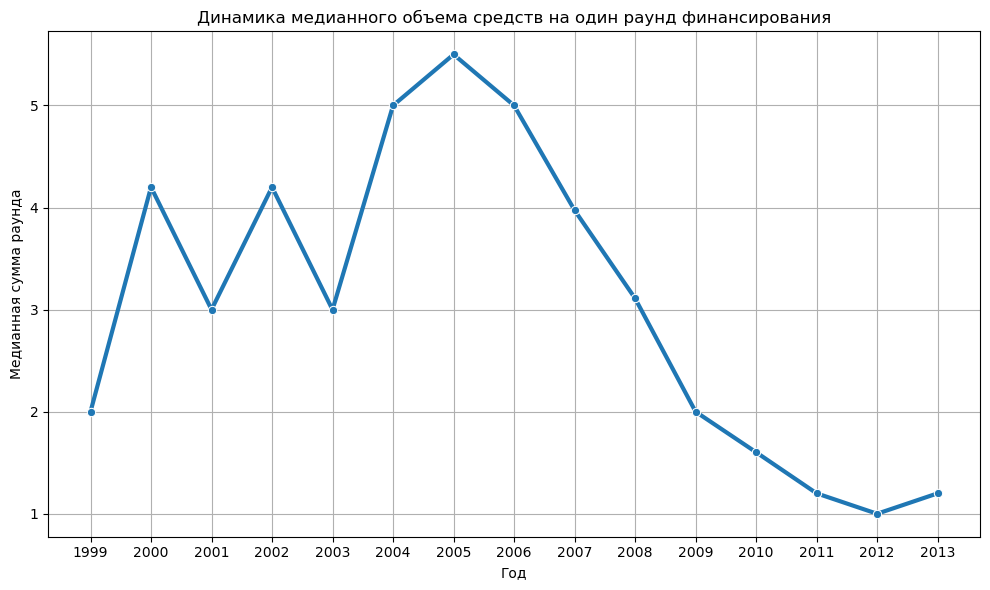

In [13]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    x=filtered_yearly_rounds.index,
    y=filtered_yearly_rounds["rounds_median"] / 1e6,
    linewidth=3,
    marker="o",
)

plt.title("Динамика медианного объема средств на один раунд финансирования")
plt.xlabel("Год")
plt.ylabel("Медианная сумма раунда")
plt.xticks(filtered_yearly_rounds.index)
plt.grid()
plt.tight_layout()
plt.show()

Ответы на вопросы: 
- 2005 год стал периодом с самым высоким медианным объемом средств в одном раунде. Сумма составила около 5,5 млн долл. 
- В 2013 г. количество раундов достигло рекордных 11072 сделок, однако медиана финансирования одного раунда составила 1,2 млн долл., что меньше пиковых значений середины 2000-х гг. 




### 2.2. Люди и их образование

Надо понять, зависит ли полнота сведений о сотрудниках (например, об их образовании) от размера компаний.

- Оценить, насколько информация об образовании сотрудников полна. Используя датасеты `people.csv` и `education.csv`, разделить все компании на несколько групп по количеству сотрудников и оценить среднюю долю сотрудников без информации об образовании в каждой из групп. Обосновать выбранные границы групп.
- Оценить, возможно ли для выполнения задания присоединить к этим таблицам ещё и таблицу `degrees.csv`.

In [14]:
df_people.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226709 entries, 0 to 226708
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                226709 non-null  int64  
 1   first_name        226700 non-null  object 
 2   last_name         226705 non-null  object 
 3   company_id        34615 non-null   float64
 4   network_username  38867 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 8.6+ MB


In [15]:
df_ed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            109610 non-null  int64 
 1   person_id     109610 non-null  int64 
 2   instituition  109555 non-null  object
 3   graduated_at  58054 non-null   object
dtypes: int64(2), object(2)
memory usage: 3.3+ MB


In [16]:
# оставим только тех сотрудников, у кого есть привязка к компании
df_employees = df_people[df_people["company_id"].notna()].copy()

# считаем количество работников в каждой компании

employees_count = df_employees.groupby("company_id")["id"].count().reset_index()

# переименовываем столбцы
employees_count.columns = ["company_id", "employees_num"]

# присоединяем датафрейм с количеством работников
df_with_empl_count = df_employees.merge(employees_count, on="company_id", how="left")

In [17]:
# посмотрим описательные статистики для количества работников

df_with_empl_count["employees_num"].describe()

count    34615.000000
mean         6.570071
std         24.914213
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max        244.000000
Name: employees_num, dtype: float64

In [18]:
# видим, что медиана равна 6,5 работникам, при этом 50% процентиль - все еще один работник. создадим границы для определения групп компаний
# создаем группы компаний по числу сотрудников
bins = [0, 1, 3, 10, 244]
labels = ["Микро", "Малые", "Средние", "Крупные"]

# категоризируем датасет
df_with_empl_count["company_group"] = pd.cut(
    df_with_empl_count["employees_num"], bins=bins, labels=labels
)

# проверяем, как распределились компании
print(df_with_empl_count["company_group"].value_counts())

company_group
Микро      18117
Малые       8181
Средние     5649
Крупные     2668
Name: count, dtype: int64


In [19]:
# проверим наличие образования у работников компаний

df_with_empl_count["has_education"] = df_with_empl_count["id"].isin(df_ed["person_id"])

df_with_empl_count.head()

,id,first_name,last_name,company_id,network_username,employees_num,company_group,has_education
0,10,Mark,Zuckerberg,5.0,NaN,61,Крупные,True
1,100,Peter,Lester,27.0,NaN,10,Средние,False
2,1000,Dr. Steven,E. Saunders,292.0,NaN,3,Малые,False
3,10000,Neil,Capel,2526.0,NaN,2,Малые,False
4,100006,Courtney,Homer,81558.0,jobsbostontech,2,Малые,True


In [20]:
# посчитаем статистику сотрудников с образованием по группам компаний

empl_education = df_with_empl_count.groupby("company_group").agg(
    {
        "has_education": ["count", "sum"],
        "employees_num": "mean",
    }  # посчитали общее количество сотрудников в группе и кол-во сотрудников с образованием + средний размер компании по кол-ву сотрудников
)

# переименуем колонки
empl_education.columns = ["total_employees", "with_ed", "avg_empl_num"]

# добавим статистику сотрудников без образования
empl_education["wo_ed_share"] = (
    (empl_education["total_employees"] - empl_education["with_ed"])
    / empl_education["total_employees"]
    * 100
)

empl_education.head()

C:\Users\kadit\AppData\Local\Temp\ipykernel_23792\3283349532.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  empl_education = df_with_empl_count.groupby("company_group").agg(


,total_employees,with_ed,avg_empl_num,wo_ed_share
company_group,,,,
Микро,18117,9736,1.000000,46.260418
Малые,8181,4311,2.337734,47.304730
Средние,5649,2737,5.840857,51.548947
Крупные,2668,1680,58.915292,37.031484


In [21]:
df_degrees.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           109610 non-null  int64 
 1   object_id    109610 non-null  object
 2   degree_type  98389 non-null   object
 3   subject      81298 non-null   object
dtypes: int64(1), object(3)
memory usage: 3.3+ MB


Промежуточный вывод: мы разделили все компании на 4 группы исходя из количества сотрудников.
- Группа 1 (1 сотрудник) - индивидуальные предприниматели, доля людей без образования - 46%; 
- Группа 2 (2-3 сотрудника) - небольшие команды-основатели стартапов, доля без образования - 47%; 
- Группа 3 (4-10 сотрудников) - средние по размеру компании, растущие стартапы, доля людей без образования - 51%; 
- Группа 4 (более 10 сотрудников) - стартапы, которые, скорее всего, получили инвестиции и масштабировались, доля людей без образования - 37%. 

Присоединить таблицу degrees можно, однако кардинально новой информации по связи образования не будет + не добавятся новые люди с записями об образовании. 

### 2.3. Объединять или не объединять — вот в чём вопрос

Некоторые названия столбцов встречаются в датасетах чаще других. В результате предварительной проверки датасетов выяснено, что столбец `company_id` подходит для объединения данных.

- Установить, подходит ли для объединения данных столбец `network_username`, который встречается в нескольких датасетах. Необходимо понимать, дублируется ли для разных датасетов информация в столбцах с таким названием, и если да — то насколько часто.
- Оценить, можно ли использовать столбцы с именем `network_username` для объединения данных.

In [22]:
# столбец network_username есть в двух датасетах: df_cr и df_people
# посчитаем, сколько полей network_username заполнено в этих датасетах и сколько там уникальных значений network_username

cr_non_null = df_cr["network_username"].notna().sum()
cr_non_null_share = df_cr["network_username"].notna().mean() * 100
cr_unique_count = df_cr["network_username"].nunique()

print(f"Анализ столбца network_username в датасете df_cr:")
print(f"Всего записей в датасете: {len(df_cr)}")
print(f"Заполненных значений в network_username: {cr_non_null}")
print(f"Доля заполненных значений в network_username: {cr_non_null_share}%")
print(f"Уникальных значений network_username: {cr_unique_count}")

Анализ столбца network_username в датасете df_cr:
Всего записей в датасете: 217774
Заполненных значений в network_username: 95534
Доля заполненных значений в network_username: 43.868414043917085%
Уникальных значений network_username: 79571


In [23]:
# делаем то же самое с датасетом df_people
people_non_null = df_people["network_username"].notna().sum()
people_non_null_share = df_people["network_username"].notna().mean() * 100
people_unique_count = df_people["network_username"].nunique()

print(f"Анализ столбца network_username в датасете df_people:")
print(f"Всего записей в датасете: {len(df_people)}")
print(f"Заполненных значений в network_username: {people_non_null}")
print(f"Доля заполненных значений в network_username: {people_non_null_share}%")
print(f"Уникальных значений network_username: {people_unique_count}")

Анализ столбца network_username в датасете df_people:
Всего записей в датасете: 226709
Заполненных значений в network_username: 38867
Доля заполненных значений в network_username: 17.14400398749057%
Уникальных значений network_username: 38421


Промежуточный вывод: можно сказать, что данных по network username в датасете people в два раза меньше, чем в датасете company_and_rounds. Уникальных значений тоже меньше в два раза, что вряд ли поможет в объединении датасетов.

In [24]:
# посчитаем дубликаты в обоих датасетах
# сначала исключаем пропуски, которые тоже считаются дубликатами

duplicates_cr = df_cr["network_username"].dropna().duplicated().sum()
print(duplicates_cr)

duplicates_people = df_people["network_username"].dropna().duplicated().sum()
print(duplicates_people)

15963
446


In [25]:
# попробуем посмотреть, какие записи в столбце network_username пересекаются в обоих датасетах
# используем метод intersection, но сначала надо создать множества из этих столбцов

cr_usernames = set(df_cr["network_username"].dropna())
people_usernames = set(df_people["network_username"].dropna())
intersected = cr_usernames.intersection(people_usernames)

print(f"кол-во уникальных значений network_username в df_cr: {len(cr_usernames)}")
print(
    f"кол-во уникальных значений network_username в df_people: {len(people_usernames)}"
)
print(f"кол-во общих значений network_username: {len(intersected)}")

кол-во уникальных значений network_username в df_cr: 79571
кол-во уникальных значений network_username в df_people: 38421
кол-во общих значений network_username: 2199


Промежуточный вывод: количество перескающихся значений в network_username незначительно - 2199, хотя в датасете df_cr всего 79571 уникальных значений, а в df_people - 38421. Учитывая также разницу в количестве записей, столбец network_username не подходит для объединения. 


### 2.4. Проблемный датасет и причина возникновения пропусков

Во время собственного анализа данных у заказчика больше всего вопросов возникло к датасету `company_and_rounds.csv`. В нём много пропусков как раз в информации о раундах, которая заказчику важна.

- Любым удобным способом привести данные в вид, который позволит в дальнейшем проводить анализ в разрезе отдельных компаний. Обратить внимание на структуру датасета, порядок и названия столбцов, проанализируйте значения.

По гипотезе заказчика данные по компаниям из этой таблицы раньше хранились иначе, более удобным для исследования образом.

- Максимальным образом сохраняя данные, сохранив их связность и исключив возможные возникающие при этом ошибки, подготовить данные так, чтобы удобно было отобрать компании по параметрам и рассчитать показатели из расчёта на одну компанию без промежуточных агрегаций.

In [26]:
df_cr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   company_id           217472 non-null  float64       
 1   name                 217471 non-null  object        
 2   category_code        143886 non-null  object        
 3   status               217472 non-null  object        
 4   founded_at           109956 non-null  datetime64[ns]
 5   closed_at            3449 non-null    datetime64[ns]
 6   domain               147159 non-null  object        
 7   network_username     95534 non-null   object        
 8   country_code         108607 non-null  object        
 9   investment_rounds    217472 non-null  float64       
 10  funding_rounds       217472 non-null  float64       
 11  funding_total        217472 non-null  float64       
 12  milestones           217472 non-null  float64       
 13  funding_round_

У нас есть слишком большая таблица company_and_rounds, где к тому же дублируется столбец company_id. Для того, чтобы в дальнейшем проводить анализ в разрезе отдельных компаний, можно разделить этот датасет на два: company и rounds. В первом случае мы возьмем столбцы: company_id, name, category_code, status, founded_at, closed_at, domain, network_username, country_code, investment_rounds, funding_rounds, funding_total, milestones. 

Во второй датасет возьмем столбцы funding_round_id, company_id, funded_at, funding_round_type, raised_amount, pre_money_valuation, participants, is_first_round, is_last_round.  

Также в первом случае удалим дубликаты в столбце company_id, чтобы получить информацию по одной компании (одна строка - одна компания). Во втором случае удалим дубликаты в столбце funding_round_id, чтобы анализировать каждый раунд отдельно. 

In [27]:
# создаем датасет компаний
companies_df = (
    df_cr.iloc[:, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]]
    .drop_duplicates(subset="company_id")
    .reset_index(drop=True)
)

In [28]:
companies_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196554 entries, 0 to 196553
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   company_id         196553 non-null  float64       
 1   name               196552 non-null  object        
 2   category_code      123186 non-null  object        
 3   status             196553 non-null  object        
 4   founded_at         91227 non-null   datetime64[ns]
 5   closed_at          2620 non-null    datetime64[ns]
 6   domain             126545 non-null  object        
 7   network_username   80591 non-null   object        
 8   country_code       87990 non-null   object        
 9   investment_rounds  196553 non-null  float64       
 10  funding_rounds     196553 non-null  float64       
 11  funding_total      196553 non-null  float64       
 12  milestones         196553 non-null  float64       
dtypes: datetime64[ns](2), float64(5), object(6)


In [29]:
# создаем датасет раундов
rounds_df = (
    df_cr.iloc[:, [13, 14, 15, 16, 17, 18, 19, 20, 21]]
    .dropna(subset=["funding_round_id"])
    .reset_index(drop=True)
)

rounds_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52928 entries, 0 to 52927
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   funding_round_id     52928 non-null  float64       
 1   company_id           52928 non-null  float64       
 2   funded_at            52680 non-null  datetime64[ns]
 3   funding_round_type   52928 non-null  object        
 4   raised_amount        52928 non-null  float64       
 5   pre_money_valuation  52928 non-null  float64       
 6   participants         52928 non-null  float64       
 7   is_first_round       52928 non-null  float64       
 8   is_last_round        52928 non-null  float64       
dtypes: datetime64[ns](1), float64(7), object(1)
memory usage: 3.6+ MB


In [30]:
# проверим, есть ли дубликаты в company_id в датасете с компаниями
dups = companies_df["company_id"].duplicated().sum()

dups

np.int64(0)

Промежуточный вывод: мы создали две отдельные таблицы на основе датасета companies_and_rounds, теперь в датасете companies_df содержится вся информация о компаниях, а в датасете rounds_df - информация о раундах инвестирования.


## Шаг 3. Исследовательский анализ объединённых таблиц



### 3.1. Объединение данных

Объединить данные для ответа на вопросы заказчика, которые касаются интересующих его компаний. Заказчика прежде всего интересуют те компании, которые меняли или готовы менять владельцев. Получение инвестиций или финансирования, по мнению заказчика, означает интерес к покупке или продаже компании.

В качестве основы для объединённой таблицы взять данные из обработанного датасета `company_and_rounds.csv` — выбрать только те компании, у которых указаны значения `funding_rounds` или `investment_rounds` больше нуля, или те, у которых в колонке `status` указано `acquired`. В результирующей таблице должно получиться порядка 40 тысяч компаний.

Проверить полноту и корректность получившейся таблицы. Далее работать только с этими данными.

In [31]:
companies_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196554 entries, 0 to 196553
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   company_id         196553 non-null  float64       
 1   name               196552 non-null  object        
 2   category_code      123186 non-null  object        
 3   status             196553 non-null  object        
 4   founded_at         91227 non-null   datetime64[ns]
 5   closed_at          2620 non-null    datetime64[ns]
 6   domain             126545 non-null  object        
 7   network_username   80591 non-null   object        
 8   country_code       87990 non-null   object        
 9   investment_rounds  196553 non-null  float64       
 10  funding_rounds     196553 non-null  float64       
 11  funding_total      196553 non-null  float64       
 12  milestones         196553 non-null  float64       
dtypes: datetime64[ns](2), float64(5), object(6)


In [32]:
# отберем интересующие нас компании
mask = (
    (companies_df["funding_rounds"] > 0)
    | (companies_df["investment_rounds"] > 0)
    | (companies_df["status"] == "acquired")
)

In [33]:
# выведем информацию о получившимся датасете

target_companies = companies_df[mask].copy()

target_companies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40747 entries, 0 to 196552
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   company_id         40747 non-null  float64       
 1   name               40747 non-null  object        
 2   category_code      35315 non-null  object        
 3   status             40747 non-null  object        
 4   founded_at         27807 non-null  datetime64[ns]
 5   closed_at          2128 non-null   datetime64[ns]
 6   domain             35754 non-null  object        
 7   network_username   20850 non-null  object        
 8   country_code       34742 non-null  object        
 9   investment_rounds  40747 non-null  float64       
 10  funding_rounds     40747 non-null  float64       
 11  funding_total      40747 non-null  float64       
 12  milestones         40747 non-null  float64       
dtypes: datetime64[ns](2), float64(5), object(6)
memory usage: 4.4+ MB

Промежуточный вывод: получили искомый датасет на 40 тысяч строк.


### 3.2. Анализ выбросов

Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

- По предобработанному столбцу `funding_total` графическим способом оценить, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся.
- В процессе расчёта значений обратить внимание, например, на показатели, возвращаемые методом `.describe()`. Применимы ли к таким данным обычные способы нахождения типичных значений?

In [34]:
# посмотрим на основные статистики по столбцу funding_total
target_companies["funding_total"].describe()

count    4.074700e+04
mean     1.013561e+07
std      5.646436e+07
min      0.000000e+00
25%      0.000000e+00
50%      6.000000e+05
75%      5.650650e+06
max      5.700000e+09
Name: funding_total, dtype: float64

Промежуточный вывод: видим, что у части стартапов нет данных о привлеченных инвестициях (столбцы min и 25-й процентиль показывают нулевые значения), при этом максимальное значение значительно превышает медиану - значит, что в данных присутствуют значительные выбросы, что будет влиять на визуализацию. 

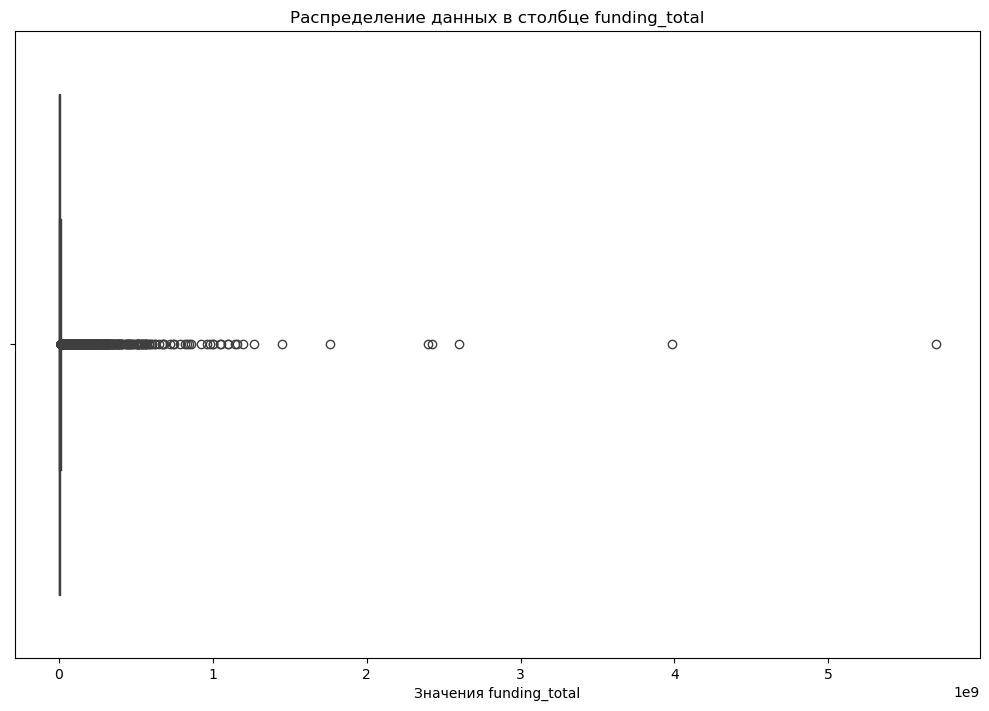

In [35]:
plt.figure(figsize=(10, 7))

sns.boxplot(data=target_companies, x="funding_total")

plt.tight_layout()
plt.title("Распределение данных в cтолбце funding_total")
plt.xlabel("Значения funding_total")
plt.show()

Видим, что данные действительно сильно искажены выбросами - скорее всего, речь идет о нескольких компаниях-единорогах - стартапах, которые привлекают финансирование более 1 млрд долл. Попробуем построить боскплот с ограничением до 95 процентился, чтобы лучше прочитать данные. 


<function matplotlib.pyplot.show(close=None, block=None)>

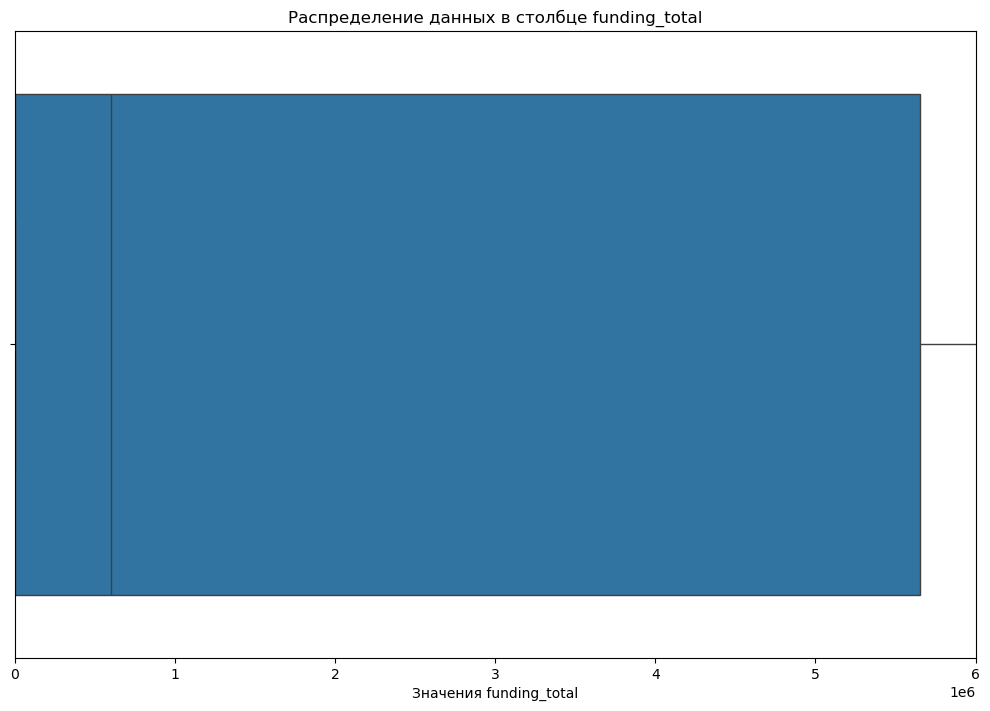

In [36]:
plt.figure(figsize=(10, 7))

sns.boxplot(data=target_companies, x="funding_total")

plt.xlim(0, companies_df["funding_total"].quantile(0.95))
plt.tight_layout()
plt.title("Распределение данных в cтолбце funding_total")
plt.xlabel("Значения funding_total")
plt.show

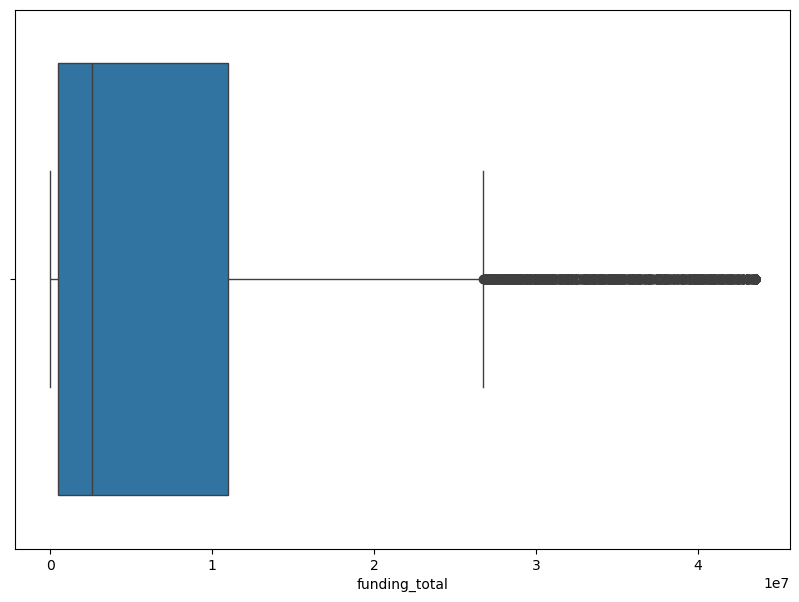

In [37]:
# попробуем построить боксплот без нулевых значений

plt.figure(figsize=(10, 7))

sns.boxplot(
    x=target_companies.loc[target_companies["funding_total"] > 0, "funding_total"].clip(
        upper=target_companies["funding_total"].quantile(0.95)
    )
)

plt.show()

Так значения читаются лучше, но они все равно в логарифмической нотации. Попробуем изобразить график с привычнми значениями. 

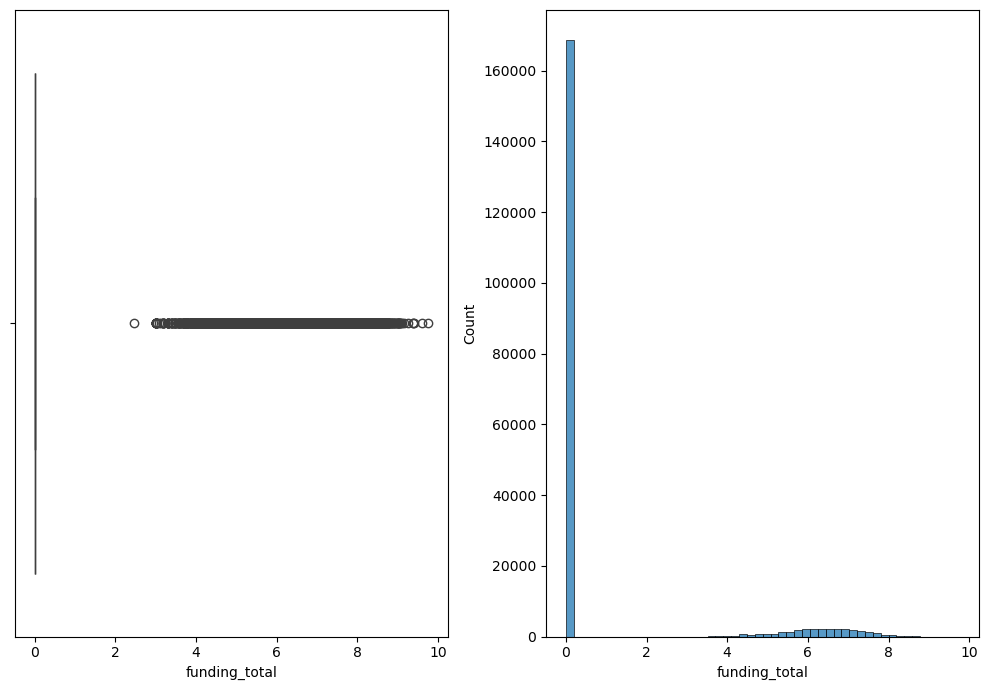

In [38]:
# делаем преобразование логарифмических значений

log_digits = np.log10(companies_df["funding_total"] + 1)

# строим боксплот и гистограмму
plt.figure(figsize=(10, 7))

plt.subplot(1, 2, 1)
sns.boxplot(x=log_digits, whis=1.5)


plt.subplot(1, 2, 2)
sns.histplot(log_digits, bins=50)

plt.tight_layout()
plt.show()

Видим, что большинство компаний или не получают финансирование, или получют его в небольшом размере, а графики искажаются максимальными значениями, которые превышают 1 млрд долл. 


### 3.3. Куплены забесплатно?

- Исследовать компании, которые были проданы за ноль или за один доллар, и при этом известно, что у них был ненулевой общий объём финансирования.

- Рассчитать аналитически верхнюю и нижнюю границу выбросов для столбца `funding_total` и укажите, каким процентилям границы соответствуют.

Для решения этой задачи нам понадобятся два датасета: 
- target_companies - будем брать оттуда информацию о компаниях с ненулевым уровням финансирования; 
- df_acq - оттуда берем id компаний, которые были проданы за 0 или 1 доллар.

In [39]:
df_acq.head()

,id,acquiring_company_id,acquired_company_id,term_code,price_amount,acquired_at
0,1,11,10,NaN,20000000,2007-05-30
1,7,59,72,cash,60000000,2007-07-01
2,8,24,132,cash,280000000,2007-05-01
3,9,59,155,cash,100000000,2007-06-01
4,10,212,215,cash,25000000,2007-07-01


In [40]:
# фильтруем сделки за 0 и 1 долл.

null_deals = df_acq[df_acq["price_amount"].isin([0, 1])].rename(
    columns={
        "acquired_company_id": "company_id"
    }  # переименовываем столбец с приобретенной компанией
)

In [41]:
# проверяем новый датафрейм
null_deals.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6934 entries, 6 to 9403
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id                    6934 non-null   int64         
 1   acquiring_company_id  6934 non-null   int64         
 2   company_id            6934 non-null   int64         
 3   term_code             642 non-null    object        
 4   price_amount          6934 non-null   int64         
 5   acquired_at           6908 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(4), object(1)
memory usage: 379.2+ KB


In [42]:
# присоединяем значения из target_companies, чтобы потом узнать про компании, приобретенные за 0 и 1 долл. с ненулевым уровнем финансирования

null_companies = null_deals.merge(
    target_companies[["company_id", "funding_total"]],
    on="company_id",
    how="inner",  # чтобы были значения из target_companies
).query(
    "funding_total > 0"
)  # фильтруем компании с ненулевым уровнем финансирования

In [43]:
null_companies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1618 entries, 1 to 6912
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id                    1618 non-null   int64         
 1   acquiring_company_id  1618 non-null   int64         
 2   company_id            1618 non-null   int64         
 3   term_code             121 non-null    object        
 4   price_amount          1618 non-null   int64         
 5   acquired_at           1614 non-null   datetime64[ns]
 6   funding_total         1618 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(4), object(1)
memory usage: 101.1+ KB


In [44]:
# считаем верхнюю и нижнюю границы выбросов

quant1 = null_companies["funding_total"].quantile(0.25)

quant3 = null_companies["funding_total"].quantile(0.75)

print(quant1, quant3)

2000000.0 15500000.0


In [45]:
# считаем межквартильный размах

iqr = quant3 - quant1

iqr

np.float64(13500000.0)

In [46]:
# считаем верхнюю и нижнюю границы

lower_b = max(
    0, quant1 - 1.5 * iqr
)  # пишем в max, потому что финансирование не может быть отрицательным
upper_b = quant3 + 1.5 * iqr

print(lower_b)
print(upper_b)

0
35750000.0


In [47]:
# выделем отдельно серию funding_total

ft = null_companies["funding_total"]

# определем процентили для каждой компании

p_lower = (
    ft <= lower_b
).mean() * 100  # тут возвращается булева серия, mean вычисляет среднее этой серии, потом умножаем на 100 и получаем процентили

p_upper = (ft <= upper_b).mean() * 100

print(p_lower)
print(p_upper)

0.0
90.91470951792337


Промежуточный вывод: нижний порог равен 0 долл. (помним, что это значение встречается для многих компаний, что мы видели на визуализации пунктом выше), верхний порог выбросов - 91%.


### 3.4. Цены стартапов по категориям

Категории стартапов с типично высокими ценами покупки стартапов и значительным разбросом цен могут быть привлекательными для крупных инвесторов, которые готовы к высоким рискам ради потенциально больших доходов. Среди категорий стартапов выделить категории стартапов, характеризующиеся:

- типично высокими ценами;
- и наибольшим разбросом цен за стартап.

Объяснить, почему решили составить топ именно из такого числа категорий и почему рассчитывали именно так.

Для решения этой задачи объединим данные из датасета df_acq c target_companies, потом рассчитаем типичные цены и посмотрим их разброс, потом сформулируем критерии для определения высоких цен и большого разрброса, потом сформулирем топ категорий по обоим критериям. 

In [48]:
# объединим датафрейм с покупками и компаниями

acquisition = (
    df_acq[
        ["acquired_company_id", "price_amount"]
    ]  # выбираем нужные поля из датасета df_acq
    .rename(
        columns={"acquired_company_id": "company_id"}
    )  # переименовываем для объединения
    .merge(
        target_companies[["company_id", "category_code"]],
        on="company_id",
        how="inner",  # делаем внутренний джойн, чтобы сохранились все поля из target_companies
    )
    .query(
        "price_amount > 0 and category_code.notna()"
    )  # исключаем нулеыве покупки и пропуски в столбцах с категорией
)

In [49]:
len(acquisition)  # всего получили 1998 сделок с финансированием больше 0

1998

In [50]:
# считаем метрики
metrics = (
    acquisition.groupby("category_code")[
        "price_amount"
    ]  # группируем по категории, считаем цену
    .agg(
        ["count", "median", "mean", "std"]
    )  # выводим количество сделок, среднее, медиану, стандартное отклонение
    .round(3)
)

# переименуем столбцы

metrics.columns = ["deals_count", "typical_price", "mean_price", "price_std"]

metrics

,deals_count,typical_price,mean_price,price_std
category_code,,,,
advertising,84,6.000000e+07,2.596701e+08,4.954839e+08
analytics,3,2.000000e+08,1.810000e+08,9.296774e+07
automotive,3,2.400000e+09,2.547667e+09,2.581669e+09
biotech,263,2.000000e+08,7.359153e+08,1.968195e+09
cleantech,39,1.850000e+08,4.823162e+08,8.744196e+08
consulting,32,3.215000e+07,2.936716e+08,1.018109e+09
ecommerce,50,1.575000e+08,2.415162e+08,2.814255e+08
education,6,1.625000e+07,1.333150e+08,2.883294e+08
enterprise,116,5.475000e+07,2.295955e+10,2.413581e+11


Для того, чтобы определить типично высокий разброс цен (порог для "типично высокого"), нам надо будет посчитать коэффициент вариации (КВ / CV). КВ - это относительная мера изменчивости, показывающая размер стандартного отклонения по отношению к среднему значению * 100%. Таким образом мы сможем посмотреть разброс относительно среднего, а не в абсолютных единицах. 

Также добавим столбец с межквартильным размахом. Для его создания используем lambda (как я понял, лямбда - это такой встроенный определитель функции сразу в коде; то есть мы заранее не определяем функцию через def, а сразу пишем ее в коде. 

In [51]:
metrics_add = (
    acquisition.groupby("category_code")["price_amount"]
    .agg(
        [
            "count",
            "median",
            "mean",
            "std",
            lambda x: x.quantile(0.75) - x.quantile(0.25),
        ]
    )
    .round(3)
)

metrics_add.columns = [
    "deals_count",
    "typical_price",
    "mean_price",
    "price_std",
    "price_iqr",
]

# добавим кэф. вариации

metrics_add["cv"] = (metrics_add["price_std"] / metrics_add["mean_price"] * 100).round(
    3
)

In [52]:
# допустим, что минимальное количество сделок для каждой категории равняется 5. отфильтруем датафрейм

min_deals_count = 5
metrics_filter = metrics_add[metrics_add["deals_count"] >= min_deals_count]

In [53]:
# определим критерии для "типично высоких цен" и "типично высокого разброса". для этого возьмем все значения, которые выше 60 процентиля

high_price_crit = metrics_filter["typical_price"].quantile(0.60)
high_cv_crit = metrics_filter["cv"].quantile(0.60)

print(
    f"порог типично высоких цен: {high_price_crit:,.0f}%"
)  # для более удобного отображения используем спецификаторы
print(f"порог большого разброса: {high_cv_crit:.1f}%")

порог типично высоких цен: 100,000,000%
порог большого разброса: 230.4%


Комментарий к коду выше: изначально я использовал пороги в 75 процентиля, но ни одной категории не нашлось. Поэтому решил снизить до 60 процентиля. 

In [54]:
# теперь найдем категории, которые соответствуют этим двум критериям

target_categories = metrics_filter[
    (metrics_filter["typical_price"] >= high_price_crit)  # критерий для цен
    & (metrics_filter["cv"] >= high_cv_crit)  # критерий для выбросов
].sort_values(
    ["typical_price", "cv"], ascending=[False, False]
)  # сортируем по убыванию

target_categories

,deals_count,typical_price,mean_price,price_std,price_iqr,cv
category_code,,,,,,
biotech,263,200000000.0,7.359153e+08,1.968195e+09,469000000.0,267.449
public_relations,74,110000000.0,1.820631e+09,6.854338e+09,389375000.0,376.481
semiconductor,71,100000000.0,4.421154e+08,1.122025e+09,248070000.0,253.786


Промежуточный вывод: установили пороги для типично высоких цен и типично высокого разброса значения на 60 перцентиле. Таким образом выявили три категории стартапов, которые соответствуют этим критериям - biotech, public_relations и semiconductor. 

Комментарий на полях: возможно, еще стоит сделать scatter_plot, где категории будут распределны на двух осях: cv и typical_price. 


### 3.5. Сколько раундов продержится стартап перед покупкой

- Необходимо проанализировать столбец `funding_rounds`. Исследуйте значения столбца. Заказчика интересует типичное значение количества раундов для каждого возможного статуса стартапа.
- Постройте график, который отображает, сколько в среднем раундов финансирования проходило для стартапов из каждой группы. Сделайте выводы.

In [55]:
# исследование столбца funding_rounds

print(f"Общая статистика по столбцу:")
print(target_companies["funding_rounds"].describe())
print("\nУникальные значения по столбцу:")
print(sorted(target_companies["funding_rounds"].unique()))
print("\nПропуски в столбце:")
print(target_companies["funding_rounds"].isna().sum())

Общая статистика по столбцу:
count    40747.000000
mean         1.291531
std          1.264604
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         15.000000
Name: funding_rounds, dtype: float64

Уникальные значения по столбцу:
[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0)]

Пропуски в столбце:
0


In [56]:
# статусы компаний

status_comp = target_companies["status"].value_counts()

status_comp

status
operating    28621
acquired      9394
closed        2092
ipo            640
Name: count, dtype: int64

In [57]:
# смотрим на основные статистики

funding_rounds_stat = (
    target_companies.groupby("status")["funding_rounds"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(3)
)

funding_rounds_stat

,count,mean,median,std,min,max
status,,,,,,
acquired,9394,0.524,0.0,1.082,0.0,12.0
closed,2092,1.381,1.0,0.835,0.0,8.0
ipo,640,1.934,1.0,2.217,0.0,13.0
operating,28621,1.523,1.0,1.215,0.0,15.0


C:\Users\kadit\AppData\Local\Temp\ipykernel_23792\3161793450.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


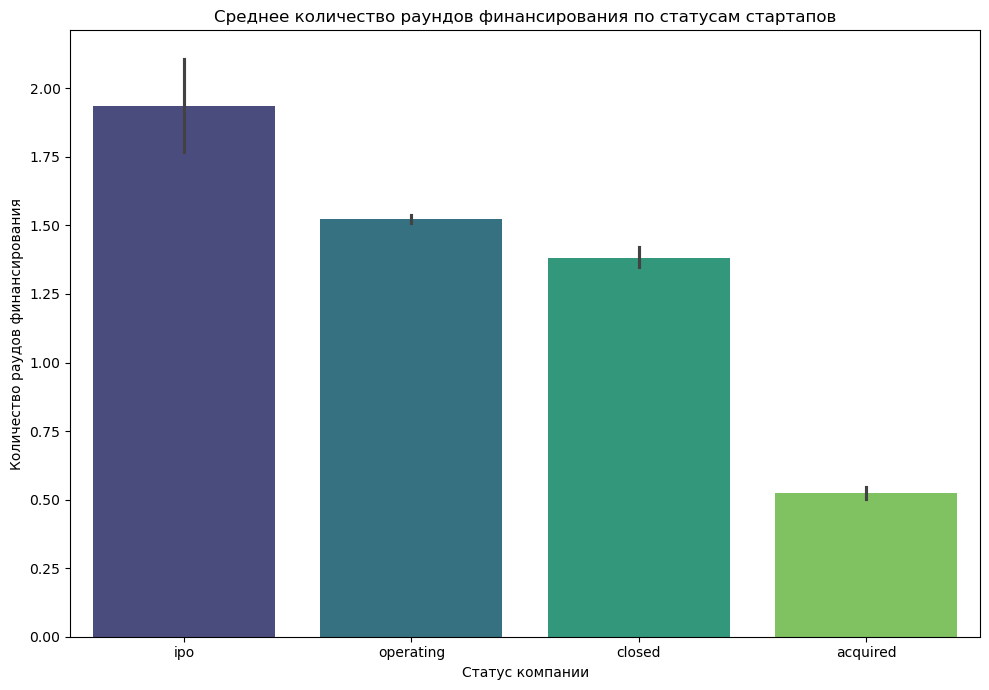

In [58]:
# строим график

plt.figure(figsize=(10, 7))

ax = sns.barplot(
    data=target_companies,
    x="status",
    y="funding_rounds",
    palette="viridis",
    order=funding_rounds_stat.sort_values("mean", ascending=False).index,
)

plt.title("Среднее количество раундов финансирования по статусам стартапов")
plt.xlabel("Статус компании")
plt.ylabel("Количество раудов финансирования")
plt.tight_layout()
plt.show()

Промежуточный вывод: анализ показал, что стартапы, которые находятся в статусе первичного выпуска акций (IPO), проходят больше всего раундов финансирования. Наименьшее значение у уже приобретенных (acquired) стартапов - значение меньше единицы.


## Шаг 4. Итоговый вывод и рекомендации

В ходе проекта необходимо было ответить на следующие вопросы: 
- по каким столбцам можно объединять данные из разных таблиц;
- можно ли доверять данным о сотрудниках стартапов и их образовании;
- что означают покупки за 0 или за 1 доллар;
- какая цена в зависимости от категории стартапов и количества раундов финансирования перед его покупкой;
- как рассчитать и отобразить численные показатели и динамику. 

Изначально мы провели работу с датасетами. Привели датасет company_and_rounds к snake_case, привели столбцы с датами в формат datetime. В датасетах встречались пропуски, однако данных было достаточно для дальнейшего анализа. 

Ответы на вопросы: 
- в ходе анализа мы пришли к выводу, что для объединения датасетов лучше всего подходит столбец company_id: 
- можно доверять данным о сотрудниках стартапов и их образовании. В ходе исследования мы разделили все компании на 4 группы исходя из количества сотрудников. При этом данные датасета education заполнены на 47%;
- покупки за 0 или 1 доллар составляют значительную часть данных о покупках. Возможно, это сделки с реструктуризацией. 
- были установлены три категории стартапов, которые совмещают высокие цены и высокий разбро (уровень "высоты" - 60 процентиль) - это biotech, semiconductors и public relations. 